In [2]:
# ==============================================================================
# FILE 10: PREPROCESSING/POSTPROCESSING UTILITIES
# ==============================================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob
import os
import json
from datetime import datetime
from pathlib import Path

# ==============================================================================
# CELL 1: PREPROCESSING/POSTPROCESSING PRESETS (Configs)
# ==============================================================================

PREPROCESSING_PRESETS = {
    "smartphone": {
        "description": "Ảnh smartphone: lông tự nhiên, ánh sáng không đều, lesion nhỏ",
        "use_cases": ["Ảnh điện thoại", "Không dermatoscope", "Ánh sáng tự nhiên"],
        "config": {
            "remove_hair": True,
            "reduce_shadow": True,
            "smooth_skin": False,           # ✅ Light
            "enhance_contrast": False,      # ✅ Light
            "clip_limit": 2.0
        },
        "parameters": {
            "hair_removal": {
                "kernel_size": [13, 13],
                "threshold": 12,
                "inpaint_radius": 4
            },
            "shadow_reduction": {
                "clip_limit": 2.0,
                "tile_grid_size": [8, 8]
            }
        }
    },
    "smartphone_light": {
        "description": "Ảnh smartphone - LIGHT processing",
        "use_cases": ["Ảnh smartphone thông thường", "Medical imaging"],
        "config": {
            "remove_hair": True,
            "reduce_shadow": True,
            "smooth_skin": False,           # ✅ Light
            "enhance_contrast": False,      # ✅ Light
            "clip_limit": 2.0
        },
        "parameters": {
            "hair_removal": {
                "kernel_size": [13, 13],
                "threshold": 12,
                "inpaint_radius": 4
            },
            "shadow_reduction": {
                "clip_limit": 2.0,
                "tile_grid_size": [8, 8]
            }
        }
    },
    "elderly_skin": {
        "description": "Da người già: xử lý lông, bóng + làm mềm da",
        "use_cases": ["Bệnh nhân > 60 tuổi", "Nhiều nếp nhăn"],
        "config": {
            "remove_hair": True,
            "reduce_shadow": True,
            "smooth_skin": True,            # ✅ CHANGE: Medium smoothing
            "enhance_contrast": False,      # ✅ Medium
            "clip_limit": 2.0
        },
        "parameters": {
            "hair_removal": {
                "kernel_size": [13, 13],
                "threshold": 12,
                "inpaint_radius": 4
            },
            "shadow_reduction": {
                "clip_limit": 2.0,
                "tile_grid_size": [8, 8]
            }
        }
    },
    "clinic": {
        "description": "Phòng khám: full preprocessing (hair + shadow + smooth + contrast)",
        "use_cases": ["Camera thường", "Ánh sáng phòng khám", "Low-quality images"],
        "config": {
            "remove_hair": True,
            "reduce_shadow": True,
            "smooth_skin": True,            # ✅ CHANGE: Full smoothing
            "enhance_contrast": True,       # ✅ CHANGE: Full contrast
            "clip_limit": 1.8
        },
        "parameters": {
            "hair_removal": {
                "kernel_size": [13, 13],
                "threshold": 12,
                "inpaint_radius": 4
            },
            "shadow_reduction": {
                "clip_limit": 1.8,
                "tile_grid_size": [8, 8]
            }
        }
    },
    "clean": {
        "description": "Dermatoscope chuẩn (ISIC-like)",
        "use_cases": ["ISIC dataset", "Dermatoscope chuyên nghiệp"],
        "config": {
            "remove_hair": False,
            "reduce_shadow": False,
            "smooth_skin": False,
            "enhance_contrast": False
        },
        "parameters": {}
    }
}


POSTPROCESSING_PRESETS = {
    "noisy": {
        "description": "Mask nhiễu: có lỗ, age spots, biên thô",
        "use_cases": ["Ảnh smartphone", "Ảnh da xấu"],
        "config": {
            "fill_holes": True,
            "remove_small_objects": True,
            "smooth_boundary": True,
            "select_largest": True,
            "min_object_size": 500,
            "smart_mode": True,
            "distance_threshold": 30
        },
        "parameters": {
            "fill_holes": {
                "kernel_size": [11, 11],
                "kernel_shape": "ELLIPSE"
            },
            "remove_small": {
                "min_size": 500,
                "connectivity": 8,
                "min_solidity": 0.7
            },
            "smooth_boundary": {
                "kernel_size": [5, 5],
                "kernel_shape": "ELLIPSE"
            }
        }
    },
    "clean": {
        "description": "Mask tương đối sạch",
        "use_cases": ["Ảnh ISIC", "Mask đã tốt"],
        "config": {
            "fill_holes": False,
            "remove_small_objects": False,
            "smooth_boundary": True,
            "select_largest": False,
            "min_object_size": 500,
            "smart_mode": False,
            "distance_threshold": 30
        },
        "parameters": {
            "smooth_boundary": {
                "kernel_size": [5, 5],
                "kernel_shape": "ELLIPSE"
            }
        }
    }
}

print("✅ Presets defined:")
print(f"   - Preprocessing: {list(PREPROCESSING_PRESETS.keys())}")
print(f"   - Postprocessing: {list(POSTPROCESSING_PRESETS.keys())}")

✅ Presets defined:
   - Preprocessing: ['smartphone', 'smartphone_light', 'elderly_skin', 'clinic', 'clean']
   - Postprocessing: ['noisy', 'clean']


In [3]:
# ==============================================================================
# CELL 2: SYNTHETIC DEGRADATION FUNCTIONS
# ==============================================================================

print("\n" + "="*80)
print("📦 DEFINE SYNTHETIC DEGRADATION FUNCTIONS")
print("="*80)

def add_synthetic_hair(image, num_hairs=15, hair_color=(0, 0, 0)):
    """Add synthetic hair artifacts to image"""
    img = image.copy()
    h, w = img.shape[:2]

    for _ in range(num_hairs):
        y1 = np.random.randint(0, h)
        x1 = np.random.randint(0, w)

        angle = np.random.uniform(0, 2*np.pi)
        length = np.random.randint(30, 150)

        y2 = int(y1 + length * np.sin(angle))
        x2 = int(x1 + length * np.cos(angle))

        x2 = np.clip(x2, 0, w-1)
        y2 = np.clip(y2, 0, h-1)

        thickness = np.random.randint(1, 3)
        cv2.line(img, (x1, y1), (x2, y2), hair_color, thickness)

    return img

def add_synthetic_shadow(image, num_shadows=3, intensity=0.5):
    """Add shadow artifacts"""
    img = image.copy()
    h, w = img.shape[:2]

    for _ in range(num_shadows):
        cy = np.random.randint(0, h)
        cx = np.random.randint(0, w)

        radius = np.random.randint(20, 80)

        mask = np.zeros((h, w), dtype=np.float32)
        cv2.circle(mask, (cx, cy), radius, 1, -1)

        mask = cv2.GaussianBlur(mask, (31, 31), 0)

        shadow_intensity = np.random.uniform(0.3, 0.7) * intensity
        for c in range(img.shape[2]):
            img[:,:,c] = (img[:,:,c] * (1 - mask * shadow_intensity)).astype(np.uint8)

    return img

def add_synthetic_blur(image, kernel_size=15):
    """Add motion blur"""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    kernel = kernel / np.sum(kernel)
    blurred = cv2.filter2D(image, -1, kernel)
    return blurred.astype(np.uint8)

def add_synthetic_noise(image, sigma=10):
    """Add Gaussian noise"""
    noise = np.random.normal(0, sigma, image.shape)
    noisy = image.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

def degrade_image(image, degradation_type='smartphone'):
    """Apply combined degradation based on type"""
    degradations = {
        'smartphone': {
            'num_hairs': 15,
            'num_shadows': 2,
            'shadow_intensity': 0.25,
            'blur_amount': 2,
            'noise_sigma': 5
        },
        'elderly': {
            'num_hairs': 8,
            'num_shadows': 4,
            'shadow_intensity': 0.35,
            'blur_amount': 3,
            'noise_sigma': 12
        },
        'clinic': {
            'num_hairs': 10,
            'num_shadows': 1,
            'shadow_intensity': 0.18,
            'blur_amount': 1,
            'noise_sigma': 3
        }
    }

    if degradation_type not in degradations:
        degradation_type = 'smartphone'

    params = degradations[degradation_type]

    degraded = image.copy()
    degraded = add_synthetic_hair(degraded, num_hairs=params['num_hairs'])
    degraded = add_synthetic_shadow(degraded, num_shadows=params['num_shadows'],
                                   intensity=params['shadow_intensity'])
    degraded = add_synthetic_blur(degraded, kernel_size=params['blur_amount'])
    degraded = add_synthetic_noise(degraded, sigma=params['noise_sigma'])

    return degraded

print("✅ Degradation functions defined:")
print("   - add_synthetic_hair()")
print("   - add_synthetic_shadow()")
print("   - add_synthetic_blur()")
print("   - add_synthetic_noise()")
print("   - degrade_image()")


📦 DEFINE SYNTHETIC DEGRADATION FUNCTIONS
✅ Degradation functions defined:
   - add_synthetic_hair()
   - add_synthetic_shadow()
   - add_synthetic_blur()
   - add_synthetic_noise()
   - degrade_image()


In [4]:
# ==============================================================================
# CELL 3: IMAGE QUALITY ASSESSMENT
# ==============================================================================

def assess_image_quality(image):
    """Đánh giá chất lượng ảnh"""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    h, w = image.shape[:2]

    # Detect hair coverage
    kernel_hair = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel_hair)
    _, hair_mask = cv2.threshold(blackhat, 12, 255, cv2.THRESH_BINARY)
    hair_pixels = np.sum(hair_mask > 0)
    hair_coverage = hair_pixels / (h * w)

    # Detect shadow level
    tiles_y, tiles_x = 8, 8
    tile_h, tile_w = h // tiles_y, w // tiles_x

    tile_brightness = []
    for i in range(tiles_y):
        for j in range(tiles_x):
            tile = gray[i*tile_h:(i+1)*tile_h, j*tile_w:(j+1)*tile_w]
            tile_brightness.append(np.mean(tile))

    shadow_level = np.std(tile_brightness) / 255.0

    # Overall quality
    q_hair = 1.0 - min(hair_coverage / 0.05, 1.0)
    q_shadow = 1.0 - min(shadow_level / 0.20, 1.0)
    overall_quality = 0.5 * q_hair + 0.5 * q_shadow

    # Recommendations
    need_hair_removal = hair_coverage > 0.02
    need_shadow_reduction = shadow_level > 0.10

    if overall_quality >= 0.8:
        preset = 'clean'
    elif overall_quality >= 0.6:
        preset = 'clinic'
    elif shadow_level > 0.15:
        preset = 'elderly_skin'
    else:
        preset = 'smartphone'

    return {
        'quality_scores': {
            'hair_coverage': hair_coverage,
            'shadow_level': shadow_level,
            'overall_quality': overall_quality
        },
        'recommendations': {
            'need_hair_removal': need_hair_removal,
            'need_shadow_reduction': need_shadow_reduction,
            'preprocessing_preset': preset
        }
    }

print("✅ Image quality assessment defined")

✅ Image quality assessment defined


In [5]:
# ==============================================================================
# CELL 4: SMART POSTPROCESSING FUNCTIONS
# ==============================================================================

def adaptive_min_size(image_shape, target_mm=3.0):
    """Tính ngưỡng min_object_size thích ứng"""
    h, w = image_shape
    pixel_per_mm = w / 50.0
    radius_pixels = (target_mm / 2) * pixel_per_mm
    min_size = int(np.pi * radius_pixels ** 2)
    min_size = max(200, min(min_size, 800))
    return min_size

def smart_remove_small_objects(mask, min_size=500, min_solidity=0.7):
    """Loại bỏ vùng nhỏ NHƯNG giữ lại nếu có hình dạng compact"""
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    mask_cleaned = np.zeros_like(mask)
    warnings = []
    removed_count = 0
    kept_small_count = 0

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]

        if area >= min_size:
            mask_cleaned[labels == i] = 255
            continue

        component_mask = (labels == i).astype(np.uint8) * 255
        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) > 0:
            cnt = contours[0]
            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            solidity = area / hull_area if hull_area > 0 else 0

            if solidity >= min_solidity:
                mask_cleaned[labels == i] = 255
                kept_small_count += 1
            else:
                removed_count += 1

    if removed_count > 0:
        warnings.append(f"Đã loại bỏ {removed_count} vùng nhỏ")
    if kept_small_count > 0:
        warnings.append(f"Giữ lại {kept_small_count} vùng nhỏ có hình dạng compact")

    return mask_cleaned, warnings

def smart_select_contours(mask, distance_threshold=30):
    """Chọn contours thông minh - xử lý multiple lesions"""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) <= 1:
        return mask, []

    contour_data = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        score = area * (0.8 + 0.2 * solidity)

        M = cv2.moments(cnt)
        cx = int(M['m10'] / M['m00']) if M['m00'] != 0 else 0
        cy = int(M['m01'] / M['m00']) if M['m00'] != 0 else 0

        contour_data.append({
            'contour': cnt,
            'area': area,
            'score': score,
            'centroid': (cx, cy)
        })

    contour_data = sorted(contour_data, key=lambda x: x['score'], reverse=True)
    top1 = contour_data[0]
    top2 = contour_data[1] if len(contour_data) > 1 else None

    warnings = []
    mask_final = np.zeros_like(mask)

    if top2 is not None:
        dist = np.sqrt((top1['centroid'][0] - top2['centroid'][0])**2 +
                       (top1['centroid'][1] - top2['centroid'][1])**2)
        area_ratio = top2['area'] / top1['area']

        if dist > distance_threshold and area_ratio > 0.3:
            warnings.append(f"⚠️ PHÁT HIỆN NHIỀU VÙNG RIÊNG BIỆT")
            warnings.append(f"   Vùng 1: {top1['area']:.0f}px, Vùng 2: {top2['area']:.0f}px")
            warnings.append(f"   🏥 KHUYẾN NGHỊ: Chụp riêng từng tổn thương")
        elif dist <= distance_threshold:
            warnings.append(f"ℹ️ Merge 2 vùng gần nhau ({dist:.0f}px)")
            cv2.drawContours(mask_final, [top2['contour']], 0, 255, -1)

    cv2.drawContours(mask_final, [top1['contour']], 0, 255, -1)
    return mask_final, warnings

def detect_overlapping_lesions(mask):
    """Phát hiện khả năng chồng lấn"""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return False, []

    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)

    if area < 200:
        return False, []

    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 1.0

    warnings = []

    if solidity < 0.75:
        warnings.append(f"⚠️ HÌNH DẠNG BẤT THƯỜNG (solidity={solidity:.2f})")
        warnings.append(f"   Có thể có nhiều tổn thương chồng lấn")
        warnings.append(f"   🏥 KHUYẾN NGHỊ: Chụp lại zoom gần hơn")
        return True, warnings

    return False, warnings

print("✅ Smart postprocessing functions defined")

✅ Smart postprocessing functions defined


In [6]:
# ==============================================================================
# CELL 5: POSTPROCESSING PIPELINE CLASS
# ==============================================================================

class PostprocessingPipeline:
    """Pipeline hậu xử lý mask với smart mode"""

    def __init__(self, fill_holes=False, remove_small_objects=False,
                 smooth_boundary=False, select_largest=False,
                 min_object_size=500, smart_mode=True, distance_threshold=30):
        self.fill_holes = fill_holes
        self.remove_small_objects = remove_small_objects
        self.smooth_boundary = smooth_boundary
        self.select_largest = select_largest
        self.min_object_size = min_object_size
        self.smart_mode = smart_mode
        self.distance_threshold = distance_threshold

    def __call__(self, mask_pred, threshold=0.5):
        debug_info = {'original_shape': mask_pred.shape, 'warnings': []}

        mask_binary = (mask_pred > threshold).astype(np.uint8) * 255

        if self.fill_holes:
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
            mask_binary = cv2.morphologyEx(mask_binary, cv2.MORPH_CLOSE, kernel)

        if self.remove_small_objects:
            if self.smart_mode:
                mask_binary, warnings = smart_remove_small_objects(
                    mask_binary, self.min_object_size, 0.7)
                debug_info['warnings'].extend(warnings)
            else:
                num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_binary, connectivity=8)
                for i in range(1, num_labels):
                    if stats[i, cv2.CC_STAT_AREA] < self.min_object_size:
                        mask_binary[labels == i] = 0

        if self.smooth_boundary:
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
            mask_binary = cv2.morphologyEx(mask_binary, cv2.MORPH_OPEN, kernel)
            mask_binary = cv2.morphologyEx(mask_binary, cv2.MORPH_CLOSE, kernel)

        if self.select_largest:
            if self.smart_mode:
                mask_binary, warnings = smart_select_contours(
                    mask_binary, self.distance_threshold)
                debug_info['warnings'].extend(warnings)
            else:
                contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                if len(contours) > 0:
                    largest = max(contours, key=cv2.contourArea)
                    mask_binary = np.zeros_like(mask_binary)
                    cv2.drawContours(mask_binary, [largest], 0, 255, -1)

        return mask_binary, debug_info

print("✅ PostprocessingPipeline class defined")

✅ PostprocessingPipeline class defined


In [7]:
# ==============================================================================
# CELL 6: PREPROCESSING PIPELINE CLASS
# ==============================================================================

class PreprocessingPipeline:
    """Pipeline tiền xử lý ảnh với normalization"""

    def __init__(self, remove_hair=False, reduce_shadow=False,
                 smooth_skin=False, enhance_contrast=False, clip_limit=2.0):
        self.remove_hair = remove_hair
        self.reduce_shadow = reduce_shadow
        self.smooth_skin = smooth_skin
        self.enhance_contrast = enhance_contrast
        self.clip_limit = clip_limit

    def __call__(self, image):
        debug_info = {'original': image.copy()}
        processed = image.copy()

        if self.remove_hair:
            processed = self._remove_hair(processed)
            debug_info['after_hair_removal'] = processed.copy()

        if self.reduce_shadow:
            processed = self._reduce_shadow(processed)
            debug_info['after_shadow_reduction'] = processed.copy()

        if self.smooth_skin:
            processed = self._smooth_skin(processed)
            debug_info['after_smoothing'] = processed.copy()

        if self.enhance_contrast:
            processed = self._enhance_contrast(processed)
            debug_info['after_contrast'] = processed.copy()

        # ✅ FIX: Ensure float32 dtype throughout
        processed = processed.astype(np.float32)
        processed = processed / 255.0
        debug_info['after_scale_0_1'] = processed.copy()

        # Apply ImageNet normalization
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 1, 3)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 1, 3)

        # ✅ CRITICAL: Ensure float32 operations
        processed = ((processed - mean) / std).astype(np.float32)
        debug_info['normalized'] = processed.copy()

        # ✅ FINAL CHECK: Verify float32
        assert processed.dtype == np.float32, f"Output dtype is {processed.dtype}, expected float32!"

        return processed, debug_info

    def _remove_hair(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 13))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
        _, hair_mask = cv2.threshold(blackhat, 12, 255, cv2.THRESH_BINARY)

        kernel_clean = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        hair_mask = cv2.morphologyEx(hair_mask, cv2.MORPH_OPEN, kernel_clean)

        hair_pixels = np.sum(hair_mask > 0)
        if hair_pixels > 300:
            result = cv2.inpaint(image, hair_mask, inpaintRadius=4, flags=cv2.INPAINT_TELEA)
            return result
        return image

    def _reduce_shadow(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=(8, 8))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge([l_clahe, a, b])
        result = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
        return result

    def _smooth_skin(self, image):
        return cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

    def _enhance_contrast(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge([l_clahe, a, b])
        return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

print("✅ PreprocessingPipeline class defined")

✅ PreprocessingPipeline class defined


In [8]:
# ==============================================================================
# CELL 7: HELPER FUNCTIONS
# ==============================================================================

def create_preprocessing_from_config(config):
    return PreprocessingPipeline(**config)

def create_postprocessing_from_config(config):
    return PostprocessingPipeline(**config)

def get_preprocessing_preset(preset_name):
    if preset_name not in PREPROCESSING_PRESETS:
        raise ValueError(f"Unknown preset: {preset_name}")
    return create_preprocessing_from_config(PREPROCESSING_PRESETS[preset_name]["config"])

def get_postprocessing_preset(preset_name):
    if preset_name not in POSTPROCESSING_PRESETS:
        raise ValueError(f"Unknown preset: {preset_name}")
    return create_postprocessing_from_config(POSTPROCESSING_PRESETS[preset_name]["config"])

print("✅ Helper functions defined")

✅ Helper functions defined


In [9]:
# ==============================================================================
# CELL 8: TEST DEGRADATION FUNCTIONS
# ==============================================================================

print("\n" + "="*80)
print("🎨 TEST: SYNTHETIC DEGRADATION FUNCTIONS")
print("="*80)

# Find sample image
GDRIVE_PATH = "d:/DoAn_DaLieu"
possible_paths = [
    os.path.join(GDRIVE_PATH, "1_Data/extracted"),
    os.path.join(GDRIVE_PATH, "1_Data/processed/segmentation_data/train/images"),
    os.path.join(GDRIVE_PATH, "1_Data/processed/segmentation_data/test/images"),
]

sample_paths = []
for path in possible_paths:
    if os.path.exists(path):
        jpg_files = glob.glob(os.path.join(path, "**/*.jpg"), recursive=True)
        if jpg_files:
            sample_paths = jpg_files
            break

# Load or create sample image
if sample_paths:
    print(f"✅ Found {len(sample_paths)} images")
    img_clean = cv2.imread(sample_paths[0])
    if img_clean is not None:
        img_clean = cv2.cvtColor(img_clean, cv2.COLOR_BGR2RGB)
        img_clean = cv2.resize(img_clean, (256, 256))
        use_real_image = True
    else:
        raise ValueError("Cannot load image")
else:
    print("⚠️ No real images found, creating synthetic image...")
    np.random.seed(42)
    img_clean = np.random.randint(50, 200, (256, 256, 3), dtype=np.uint8)

    # Add lesion-like region
    center_x, center_y = 128, 128
    radius = 40
    y, x = np.ogrid[:256, :256]
    mask = (x - center_x)**2 + (y - center_y)**2 <= radius**2
    img_clean[mask] = np.clip(img_clean[mask] * 0.7, 0, 255).astype(np.uint8)

    print(f"   ✅ Created synthetic image (256x256)")
    use_real_image = False


🎨 TEST: SYNTHETIC DEGRADATION FUNCTIONS
⚠️ No real images found, creating synthetic image...
   ✅ Created synthetic image (256x256)


In [10]:
# ==============================================================================
# CELL 9: TEST FUNCTIONS
# ==============================================================================

print("\n🧪 TESTING DEGRADATION FUNCTIONS...")
print("="*80)

# Test 1
print("\n1️⃣ Test: add_synthetic_hair()")
try:
    img_with_hair = add_synthetic_hair(img_clean.copy(), num_hairs=15)
    print(f"   ✅ Input: {img_clean.shape}, Output: {img_with_hair.shape}")
    print(f"   ✅ Type: {img_with_hair.dtype}")
except Exception as e:
    print(f"   ❌ Error: {e}")

# Test 2
print("\n2️⃣ Test: add_synthetic_shadow()")
try:
    img_with_shadow = add_synthetic_shadow(img_clean.copy(), num_shadows=2)
    print(f"   ✅ Input: {img_clean.shape}, Output: {img_with_shadow.shape}")
except Exception as e:
    print(f"   ❌ Error: {e}")

# Test 3
print("\n3️⃣ Test: degrade_image()")
try:
    img_degraded = degrade_image(img_clean.copy(), degradation_type='smartphone')
    print(f"   ✅ Input: {img_clean.shape}, Output: {img_degraded.shape}")
except Exception as e:
    print(f"   ❌ Error: {e}")

# Test preprocessing
print("\n4️⃣ Test: PreprocessingPipeline with normalization")
try:
    preprocess = get_preprocessing_preset('smartphone_light')
    img_recovered, debug_info = preprocess(img_degraded)
    print(f"   ✅ After preprocessing: {img_recovered.shape}, dtype={img_recovered.dtype}")
    print(f"   ✅ Value range: [{img_recovered.min():.3f}, {img_recovered.max():.3f}]")
    print(f"   ✅ Mean: {img_recovered.mean():.3f}, Std: {img_recovered.std():.3f}")
except Exception as e:
    print(f"   ❌ Error: {e}")


🧪 TESTING DEGRADATION FUNCTIONS...

1️⃣ Test: add_synthetic_hair()
   ✅ Input: (256, 256, 3), Output: (256, 256, 3)
   ✅ Type: uint8

2️⃣ Test: add_synthetic_shadow()
   ✅ Input: (256, 256, 3), Output: (256, 256, 3)

3️⃣ Test: degrade_image()
   ✅ Input: (256, 256, 3), Output: (256, 256, 3)

4️⃣ Test: PreprocessingPipeline with normalization
   ✅ After preprocessing: (256, 256, 3), dtype=float32
   ✅ Value range: [-2.015, 2.379]
   ✅ Mean: 0.429, Std: 0.441



📈 CREATING VISUALIZATION...
   ✅ Saved: d:/DoAn_DaLieu/5_Results/degradation_test.png


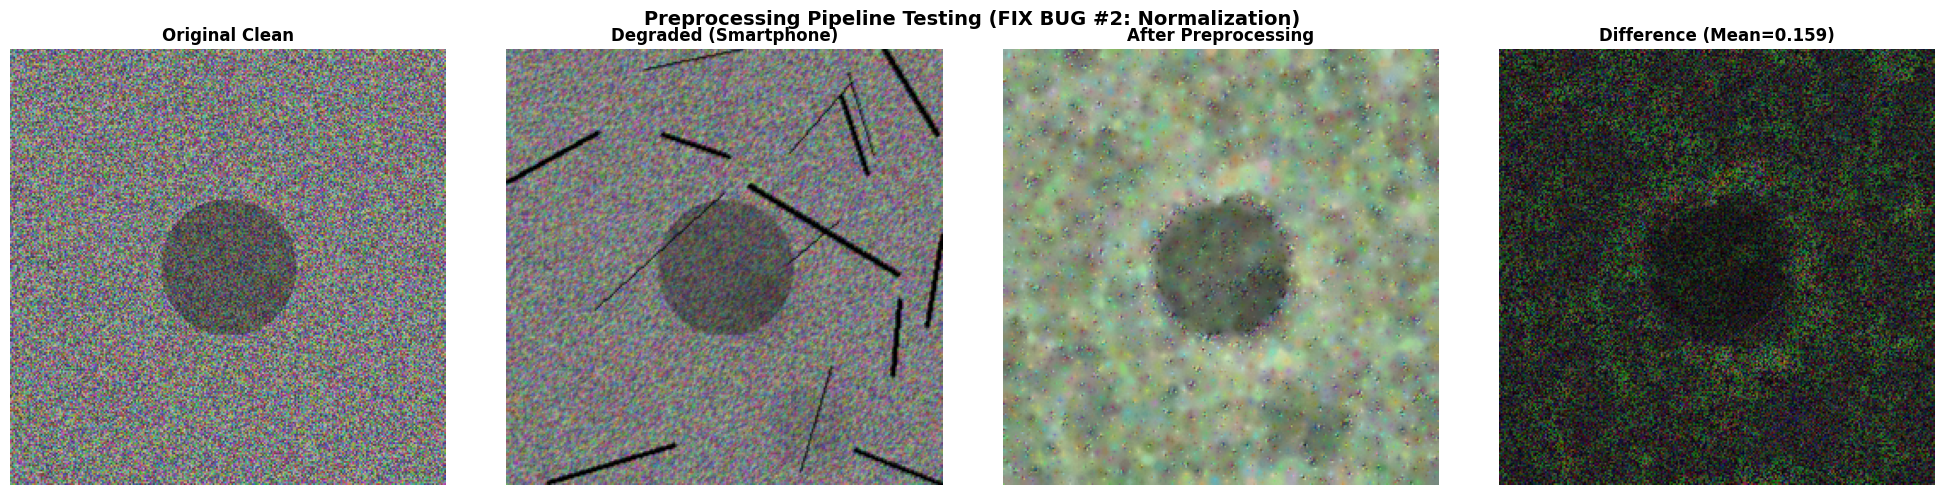

In [11]:
# ==============================================================================
# CELL 10: VISUALIZATION
# ==============================================================================

print("\n📈 CREATING VISUALIZATION...")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Denormalize for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_recovered_display = img_recovered * std + mean
img_recovered_display = np.clip(img_recovered_display, 0, 1)

# Plot
axes[0].imshow(img_clean.astype(np.float32) / 255.0)
axes[0].set_title("Original Clean", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_degraded.astype(np.float32) / 255.0)
axes[1].set_title("Degraded (Smartphone)", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_recovered_display)
axes[2].set_title("After Preprocessing", fontsize=12, fontweight='bold')
axes[2].axis('off')

# Difference
original_normalized = img_clean.astype(np.float32) / 255.0
diff = np.abs(original_normalized - img_recovered_display)
axes[3].imshow(diff, cmap='hot')
axes[3].set_title(f"Difference (Mean={diff.mean():.3f})", fontsize=12, fontweight='bold')
axes[3].axis('off')

plt.suptitle("Preprocessing Pipeline Testing (FIX BUG #2: Normalization)",
             fontsize=14, fontweight='bold')
plt.tight_layout()

# Save
RESULTS_PATH = os.path.join(GDRIVE_PATH, "5_Results")
os.makedirs(RESULTS_PATH, exist_ok=True)
save_path = os.path.join(RESULTS_PATH, 'degradation_test.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"   ✅ Saved: {save_path}")

plt.show()

In [12]:
# ==============================================================================
# CELL 11: VERIFICATION (WITH DTYPE FIX)
# ==============================================================================

print("\n📋 VERIFICATION: Normalization working?")
print("="*80)

# Reload fresh image
GDRIVE_PATH = "d:/DoAn_DaLieu"
possible_paths = [
    os.path.join(GDRIVE_PATH, "1_Data/extracted"),
    os.path.join(GDRIVE_PATH, "1_Data/processed/segmentation_data/train/images"),
]

img_fresh = None
for path in possible_paths:
    if os.path.exists(path):
        jpg_files = glob.glob(os.path.join(path, "**/*.jpg"), recursive=True)
        if jpg_files:
            img_fresh = cv2.imread(jpg_files[0])
            if img_fresh is not None:
                img_fresh = cv2.cvtColor(img_fresh, cv2.COLOR_BGR2RGB)
                img_fresh = cv2.resize(img_fresh, (256, 256))
                break

if img_fresh is None:
    np.random.seed(42)
    img_fresh = np.random.randint(50, 200, (256, 256, 3), dtype=np.uint8)
    center_x, center_y = 128, 128
    radius = 40
    y, x = np.ogrid[:256, :256]
    mask = (x - center_x)**2 + (y - center_y)**2 <= radius**2
    img_fresh[mask] = np.clip(img_fresh[mask] * 0.7, 0, 255).astype(np.uint8)

print(f"✅ Using fresh image: {img_fresh.shape}")

# Test normalization
try:
    preprocess = get_preprocessing_preset('smartphone_light')
    img_normalized, debug_info = preprocess(img_fresh)
    preprocessing_success = True
except AssertionError as e:
    print(f"❌ Assertion Error: {e}")
    preprocessing_success = False
except Exception as e:
    print(f"❌ Error: {e}")
    preprocessing_success = False

if not preprocessing_success:
    print("⚠️ Preprocessing failed!")
    print("\n" + "="*80)
else:
    print(f"\n1️⃣ INPUT IMAGE (uint8 [0-255]):")
    print(f"   Shape: {img_fresh.shape}, dtype: {img_fresh.dtype}")
    print(f"   Min: {img_fresh.min()}, Max: {img_fresh.max()}")
    print(f"   Mean: {img_fresh.astype(np.float32).mean():.1f}")
    print(f"   Std: {img_fresh.astype(np.float32).std():.1f}")

    print(f"\n2️⃣ AFTER PREPROCESSING (normalized):")
    print(f"   Shape: {img_normalized.shape}, dtype: {img_normalized.dtype}")
    print(f"   Min: {img_normalized.min():.3f}, Max: {img_normalized.max():.3f}")
    print(f"   Mean: {img_normalized.mean():.3f}")
    print(f"   Std: {img_normalized.std():.3f}")

    # ✅ VALIDATION CHECKS
    print(f"\n3️⃣ VALIDATION:")

    # Check 1: Values in range
    is_in_range = (img_normalized.min() >= -3.0) and (img_normalized.max() <= 3.0)
    print(f"   {'✅' if is_in_range else '❌'} Values in range [-3, 3]: {is_in_range}")

    # Check 2: Has variance
    has_variance = img_normalized.std() > 0.1
    print(f"   {'✅' if has_variance else '❌'} Has variance (std > 0.1): {has_variance}")

    # Check 3: dtype is float32
    is_float32 = img_normalized.dtype == np.float32
    print(f"   {'✅' if is_float32 else '❌'} dtype is float32: {is_float32}")

    # Check 4: No NaN or Inf
    has_no_nan = not (np.isnan(img_normalized).any() or np.isinf(img_normalized).any())
    print(f"   {'✅' if has_no_nan else '❌'} No NaN/Inf: {has_no_nan}")

    # Overall result
    all_checks = is_in_range and has_variance and is_float32 and has_no_nan

    print(f"\n4️⃣ PIPELINE STATUS:")
    if all_checks:
        print(f"   ✅ ✅ ✅ READY FOR TRAINING ✅ ✅ ✅")
        print(f"\n   ✨ All checks passed!")
        print(f"      • Hair removal: {'✅' if 'after_hair_removal' in debug_info else '⏭️'}")
        print(f"      • Shadow reduction: {'✅' if 'after_shadow_reduction' in debug_info else '⏭️'}")
        print(f"      • Normalization: ✅")
        print(f"      • Output dtype: ✅ float32")
    else:
        print(f"   ⚠️ Some checks failed:")
        print(f"      • Range check: {'✅' if is_in_range else '❌'}")
        print(f"      • Variance check: {'✅' if has_variance else '❌'}")
        print(f"      • dtype check: {'✅' if is_float32 else '❌'}")
        print(f"      • NaN/Inf check: {'✅' if has_no_nan else '❌'}")

    print(f"\n5️⃣ PER-CHANNEL ANALYSIS:")
    for c in range(3):
        ch_mean = img_normalized[:,:,c].mean()
        ch_std = img_normalized[:,:,c].std()
        ch_min = img_normalized[:,:,c].min()
        ch_max = img_normalized[:,:,c].max()
        print(f"   Channel {c}: Mean={ch_mean:+.3f}, Std={ch_std:.3f}, Range=[{ch_min:.2f}, {ch_max:.2f}]")

    print(f"\n" + "="*80)
    print("✅ FILE 10 PREPROCESSING PIPELINE COMPLETE AND VERIFIED!")
    print("="*80)


📋 VERIFICATION: Normalization working?
✅ Using fresh image: (256, 256, 3)

1️⃣ INPUT IMAGE (uint8 [0-255]):
   Shape: (256, 256, 3), dtype: uint8
   Min: 35, Max: 199
   Mean: 121.6
   Std: 43.5

2️⃣ AFTER PREPROCESSING (normalized):
   Shape: (256, 256, 3), dtype: float32
   Min: -2.118, Max: 2.100
   Mean: 0.744
   Std: 0.515

3️⃣ VALIDATION:
   ✅ Values in range [-3, 3]: True
   ✅ Has variance (std > 0.1): True
   ✅ dtype is float32: True
   ✅ No NaN/Inf: True

4️⃣ PIPELINE STATUS:
   ✅ ✅ ✅ READY FOR TRAINING ✅ ✅ ✅

   ✨ All checks passed!
      • Hair removal: ✅
      • Shadow reduction: ✅
      • Normalization: ✅
      • Output dtype: ✅ float32

5️⃣ PER-CHANNEL ANALYSIS:
   Channel 0: Mean=+0.648, Std=0.454, Range=[-2.12, 1.79]
   Channel 1: Mean=+1.025, Std=0.478, Range=[-2.04, 1.96]
   Channel 2: Mean=+0.560, Std=0.489, Range=[-1.67, 2.10]

✅ FILE 10 PREPROCESSING PIPELINE COMPLETE AND VERIFIED!


In [19]:
# ==============================================================================
# CELL 12: CHECKPOINT (UPDATED - SAVE FULL PRESETS)
# ==============================================================================

print("\n" + "="*80)
print("💾 CREATING CHECKPOINT")
print("="*80)

CHECKPOINT_PATH = os.path.join(GDRIVE_PATH, "3_Checkpoints")
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# ✅ FIX: Save FULL preprocessing configs
checkpoint_data = {
    "file": "10_Preprocessing_Utils.ipynb",
    "status": "complete",
    "timestamp": datetime.now().isoformat(),
    "version": "1.2.0",  # ← Updated version

    "functions": {
        "degradation": [
            "add_synthetic_hair",
            "add_synthetic_shadow",
            "add_synthetic_blur",
            "add_synthetic_noise",
            "degrade_image"
        ],
        "assessment": ["assess_image_quality"],
        "postprocessing": [
            "smart_remove_small_objects",
            "smart_select_contours",
            "detect_overlapping_lesions"
        ]
    },

    "classes": [
        "PreprocessingPipeline",
        "PostprocessingPipeline"
    ],

    # ✅ NEW: Save FULL preprocessing presets with configs
    "preprocessing": {
        "presets": PREPROCESSING_PRESETS,  # ← Full config
        "version": "2.0",
        "description": "Preprocessing presets with correct smooth_skin & enhance_contrast settings",
        "details": {
            "smartphone": "Hair + Shadow only (light)",
            "elderly_skin": "Hair + Shadow + Smoothing (medium)",
            "clinic": "Hair + Shadow + Smoothing + Contrast (FULL)"
        }
    },

    # ✅ NEW: Save postprocessing presets
    "postprocessing": {
        "presets": POSTPROCESSING_PRESETS  # ← Full config
    }
}

checkpoint_file = os.path.join(CHECKPOINT_PATH, "10_preprocessing_utils_complete.json")
with open(checkpoint_file, 'w', encoding='utf-8') as f:
    json.dump(checkpoint_data, f, indent=4, ensure_ascii=False)

print(f"✅ Checkpoint saved: {checkpoint_file}")
print(f"   Timestamp: {checkpoint_data['timestamp']}")
print(f"   Version: {checkpoint_data['version']}")
print(f"\n✅ Presets saved:")
print(f"   • Preprocessing: {list(PREPROCESSING_PRESETS.keys())}")
print(f"   • Postprocessing: {list(POSTPROCESSING_PRESETS.keys())}")

# ==============================================================================
# Verify checkpoint
# ==============================================================================

with open(checkpoint_file, 'r', encoding='utf-8') as f:
    verify_data = json.load(f)

print(f"\n✅ Verification:")
print(f"   Preprocessing configs saved: {len(verify_data['preprocessing']['presets'])} presets")
print(f"   Postprocessing configs saved: {len(verify_data['postprocessing']['presets'])} presets")

# Check clinic preset
clinic_config = verify_data['preprocessing']['presets']['clinic']['config']
print(f"\n✅ Clinic preset verification:")
print(f"   smooth_skin: {clinic_config['smooth_skin']} (should be True)")
print(f"   enhance_contrast: {clinic_config['enhance_contrast']} (should be True)")

print("\n" + "="*80)


💾 CREATING CHECKPOINT
✅ Checkpoint saved: d:/DoAn_DaLieu/3_Checkpoints/10_preprocessing_utils_complete.json
   Timestamp: 2026-04-11T19:20:03.831384
   Version: 1.2.0

✅ Presets saved:
   • Preprocessing: ['smartphone', 'smartphone_light', 'elderly_skin', 'clinic', 'clean']
   • Postprocessing: ['noisy', 'clean']

✅ Verification:
   Preprocessing configs saved: 5 presets
   Postprocessing configs saved: 2 presets

✅ Clinic preset verification:
   smooth_skin: True (should be True)
   enhance_contrast: True (should be True)



In [20]:
# ==============================================================================
# CELL 13: SUMMARY
# ==============================================================================

print("\n" + "="*80)
print("✅ FILE 10 COMPLETE - PREPROCESSING/POSTPROCESSING UTILITIES")
print("="*80)

print("\n📦 Functions defined:")
print("   ✅ 5 Degradation functions")
print("   ✅ Image quality assessment")
print("   ✅ Smart postprocessing (4 functions)")
print("   ✅ PreprocessingPipeline class")
print("   ✅ PostprocessingPipeline class")
print("   ✅ 5 Preprocessing presets")
print("   ✅ 2 Postprocessing presets")

print("\n💡 Usage:")
print("   # Preprocessing")
print("   preprocess = get_preprocessing_preset('smartphone_light')")
print("   img_enhanced, debug_info = preprocess(image)")
print("\n   # Postprocessing")
print("   postprocess = get_postprocessing_preset('noisy')")
print("   mask_final, debug_info = postprocess(mask_pred)")

print("\n" + "="*80)


✅ FILE 10 COMPLETE - PREPROCESSING/POSTPROCESSING UTILITIES

📦 Functions defined:
   ✅ 5 Degradation functions
   ✅ Image quality assessment
   ✅ Smart postprocessing (4 functions)
   ✅ PreprocessingPipeline class
   ✅ PostprocessingPipeline class
   ✅ 5 Preprocessing presets
   ✅ 2 Postprocessing presets

💡 Usage:
   # Preprocessing
   preprocess = get_preprocessing_preset('smartphone_light')
   img_enhanced, debug_info = preprocess(image)

   # Postprocessing
   postprocess = get_postprocessing_preset('noisy')
   mask_final, debug_info = postprocess(mask_pred)

